# Tréning modelov — Australia Weather

**Klasifikácia** (RainTomorrow): Decision Tree, Logistic Regression, Random Forest  
**Regresia** (RISK_MM): Gradient Boosting  
**Feature sety**: selected, no_critical, all

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['OMP_NUM_THREADS'] = '1'

from sklearn.model_selection import StratifiedKFold, KFold, cross_validate, cross_val_predict, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, mean_absolute_error,
                             mean_squared_error, r2_score)
from scipy.stats import randint, uniform

In [ ]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
os.makedirs('outputs', exist_ok=True)

In [ ]:
df = pd.read_csv('data/australia_weather_transformed.csv')
print(f"Dataset: {df.shape}")

Dataset: (156412, 91)


In [ ]:
df.columns

Index(['Date', 'Location', 'Lat', 'Lon', 'Region', 'Month', 'DayOfYear',
       'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 'Temp_change',
       'MinTemp_imputed', 'MaxTemp_imputed', 'Temp9am_imputed',
       'Temp3pm_imputed', 'Temp_change_imputed', 'Rainfall', 'Rainfall_log',
       'RainToday', 'RISK_MM', 'RainTomorrow', 'Rainfall_imputed',
       'Rainfall_log_imputed', 'RainToday_imputed', 'Evaporation',
       'Evaporation_log', 'Sunshine', 'Evaporation_imputed',
       'Evaporation_log_imputed', 'Sunshine_imputed', 'WindGustSpeed',
       'WindGustSpeed_log', 'WindSpeed9am', 'WindSpeed3pm', 'WindSpeed_change',
       'WindGustSpeed_imputed', 'WindGustSpeed_log_imputed',
       'WindSpeed9am_imputed', 'WindSpeed3pm_imputed',
       'WindSpeed_change_imputed', 'WindGustDir', 'WindGustDir_degree',
       'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am', 'WindDir9am_degree',
       'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm', 'WindDir3pm_degree',
       'WindDir3pm_sin', 'Wi

In [ ]:
df_orig = pd.read_csv('data/australia_weather.csv')
print(f"Dataset: {df_orig.shape}")

Dataset: (156412, 47)


In [ ]:
df_orig.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow', 'Month', 'DayOfYear',
       'WindGustDir_degree', 'WindGustDir_sin', 'WindGustDir_cos',
       'WindDir9am_degree', 'WindDir9am_sin', 'WindDir9am_cos',
       'WindDir3pm_degree', 'WindDir3pm_sin', 'WindDir3pm_cos',
       'WindSpeed_change', 'WindDir_degree_change', 'Pressure_change',
       'Cloud_change', 'Temp_change', 'Humidity_change', 'Humidity_Pressure9',
       'Humidity_Pressure3', 'Humidity_Pressure_change', 'Rainfall_log',
       'Evaporation_log', 'WindGustSpeed_log'],
      dtype='object')

## Konfigurácia
### Feature sety

In [ ]:
# === Feature sety ===

# Set 1: Vybrané (3pm + zmeny)
features_selected = [
    'Region',
    'MinTemp', 'MaxTemp', 'Temp3pm', 'Temp_change',
    'Rainfall_log', 'RainToday',          # <- log namiesto Rainfall
    'Evaporation_log', 'Sunshine',        # <- log namiesto Evaporation
    'WindGustSpeed_log', 'WindSpeed3pm', 'WindSpeed_change',  # <- log
    'WindDir_degree_change',
    'Humidity3pm', 'Humidity_change',
    'Pressure3pm', 'Pressure_change',
    'Cloud3pm', 'Cloud_change',
    'Month', 'DayOfYear',
]

# Set 2: Bez kritických (Evaporation, Sunshine, Cloud)
features_no_critical = [f for f in features_selected
                        if not any(x in f for x in ['Evaporation', 'Sunshine', 'Cloud'])]

# Set 3: Všetky
exclude = ['RainTomorrow', 'RISK_MM', 'Location', 'Lat', 'Lon']
features_all = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude]

feature_sets = {
    'selected': features_selected,
    'no_critical': features_no_critical,
    'all': features_all,
}
# Pridať imputed flagy ku každému setu
for name in ['selected', 'no_critical', 'all']:
    base = eval(f'features_{name}')
    flags = [c + '_imputed' for c in base if c + '_imputed' in df.columns]
    exec(f'features_{name} = base + flags')

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")

print(f'orig: {df_orig.shape[1]} features')


selected: 21 features
no_critical: 17 features
all: 82 features
orig: 47 features


In [ ]:
cat_cols = make_column_selector(dtype_include=object)
num_cols = make_column_selector(dtype_exclude=object)

## Klasifikačné modely

### Targety

In [ ]:
# === Targety ===
y_cls = df['RainTomorrow']

# === CV stratégia ===
cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Pipeline

In [ ]:
# Decision tree
tree_pipeline = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(handle_unknown = 'ignore'), cat_cols),
        remainder = 'passthrough'
    ),
    DecisionTreeClassifier(random_state = 42)
)

In [ ]:
# Logistic Regression
logistic_pipeline = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(handle_unknown='ignore'), cat_cols),
        (StandardScaler(), num_cols)
    ),
    LogisticRegression(max_iter=1000, random_state=42)
)

In [ ]:
# Random Forest
forestClass_pipeline = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(handle_unknown = 'ignore'), cat_cols),
        remainder = 'passthrough'
    ),
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
)

In [ ]:
## Klasifikácia (RainTomorrow)
clf_models = {
    'DecisionTree': tree_pipeline,
    'LogisticRegression': logistic_pipeline,
    'RandomForest': forestClass_pipeline
}


### Evaluácia modelov

In [ ]:
def eval_classifier(model, X, y, cv):
    """Cross-validated klasifikačné metriky."""
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {m: scores[f'test_{m}'].mean() for m in scoring}

### Natrénované modely (základné)

In [ ]:
results = []

# --- Klasifikácia ---
for model_name, model in clf_models.items():
    for fs_name, fs_cols in feature_sets.items():
        X = df[fs_cols]
        scores = eval_classifier(model, X, y_cls, cv_cls)
        results.append({'model': model_name, 'features': fs_name, 'target': 'RainTomorrow', **scores})
        print(f"{model_name:20s} | {fs_name:12s} | Acc={scores['accuracy']:.4f}  Prec={scores['precision']:.4f}  Rec={scores['recall']:.4f}  F1={scores['f1']:.4f}  AUC={scores['roc_auc']:.4f}")


DecisionTree         | selected     | Acc=0.8177  Prec=0.5905  Rec=0.6076  F1=0.5989  AUC=0.7430
DecisionTree         | no_critical  | Acc=0.8131  Prec=0.5798  Rec=0.6017  F1=0.5906  AUC=0.7379
DecisionTree         | all          | Acc=0.8199  Prec=0.5955  Rec=0.6111  F1=0.6032  AUC=0.7457
LogisticRegression   | selected     | Acc=0.8421  Prec=0.7165  Rec=0.4879  F1=0.5805  AUC=0.8619
LogisticRegression   | no_critical  | Acc=0.8397  Prec=0.7176  Rec=0.4684  F1=0.5668  AUC=0.8521
LogisticRegression   | all          | Acc=0.8457  Prec=0.7227  Rec=0.5046  F1=0.5942  AUC=0.8691
RandomForest         | selected     | Acc=0.8786  Prec=0.8212  Rec=0.5855  F1=0.6836  AUC=0.9142
RandomForest         | no_critical  | Acc=0.8757  Prec=0.8139  Rec=0.5767  F1=0.6751  AUC=0.9079
RandomForest         | all          | Acc=0.8794  Prec=0.8224  Rec=0.5888  F1=0.6863  AUC=0.9173


### Natrénované modely (základné) na pôvodných dátach

In [ ]:
cat_selector = make_column_selector(dtype_include=object)
num_selector = make_column_selector(dtype_exclude=object)

# Preprocessing pre tree modely (nepotrebujú scaling)
orig_tree_prep = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat_selector),
    (SimpleImputer(strategy='median'), num_selector)
)

# Preprocessing pre lineárne modely (scaling)
orig_linear_prep = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat_selector),
    (make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_selector)
)

# Pipelines
orig_tree_pipeline = make_pipeline(orig_tree_prep, DecisionTreeClassifier(random_state=42))
orig_logistic_pipeline = make_pipeline(orig_linear_prep, LogisticRegression(max_iter=1000, random_state=42))
orig_forest_pipeline = make_pipeline(orig_tree_prep, RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))

In [ ]:
# Data z originalneho datasetu
X = df_orig.drop(columns = ['RISK_MM', 'RainTomorrow'])
y = df_orig.RainTomorrow

In [ ]:
scores = eval_classifier(orig_tree_pipeline, X, y, cv_cls)
results.append({'model': 'DecisionTree', 'features': 'original', 'target': 'RainTomorrow', **scores})
print(f"DecisionTree | original | Acc={scores['accuracy']:.4f}  Prec={scores['precision']:.4f}  Rec={scores['recall']:.4f}  F1={scores['f1']:.4f}  AUC={scores['roc_auc']:.4f}")


DecisionTree | original | Acc=0.8387  Prec=0.6488  Rec=0.6099  F1=0.6287  AUC=0.7573


In [ ]:
scores = eval_classifier(orig_logistic_pipeline, X, y, cv_cls)
results.append({'model': 'LogisticRegression', 'features': 'original', 'target': 'RainTomorrow', **scores})
print(f"LogisticRegression | original | Acc={scores['accuracy']:.4f}  Prec={scores['precision']:.4f}  Rec={scores['recall']:.4f}  F1={scores['f1']:.4f}  AUC={scores['roc_auc']:.4f}")


LogisticRegression | original | Acc=0.8553  Prec=0.7349  Rec=0.5538  F1=0.6316  AUC=0.8874


## Regresné modely

### TargetY

In [ ]:
# === Targety ===
y_reg = np.log(df['RISK_MM']+0.1)

# === CV stratégia ===
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

### Pipeline

In [ ]:
linear_pipeline = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(handle_unknown='ignore'), cat_cols),
        (StandardScaler(), num_cols)
    ),
    LinearRegression()
)

In [ ]:
# Random Forest Regressor
forestReg_pipeline = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(handle_unknown = 'ignore'), cat_cols),
        remainder = 'passthrough'
    ),
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
)

In [ ]:
# GradientBoosting
gradient_pipeline = make_pipeline(
    make_column_transformer(
        (OneHotEncoder(handle_unknown = 'ignore'), cat_cols),
        remainder = 'passthrough'
    ),
    HistGradientBoostingRegressor(max_iter=200, random_state=42))

In [ ]:
# Regresia (RISK_MM) — HistGradientBoosting zvláda NaN natívne,
reg_models = {
    'LinearRegression': linear_pipeline,
    'RandomForestRegressor': forestReg_pipeline,
    'GradientBoosting': gradient_pipeline,
}

### Evaluácia modelov

In [ ]:
def eval_regressor(model, X, y_reg, y_cls, cv):
    """Cross-validated regresné metriky + odvodená klasifikácia (>=1mm → dážď)."""
    y_pred = cross_val_predict(model, X, y_reg, cv=cv, n_jobs=1)

    # Regresné metriky
    result = {
        'MAE': mean_absolute_error(y_reg, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_reg, y_pred)),
        'R2': r2_score(y_reg, y_pred),
    }

    # Odvodená klasifikácia: predikcia >= 1mm → RainTomorrow = 1
    y_pred_cls = (y_pred >= 1).astype(int)
    result['derived_f1'] = f1_score(y_cls, y_pred_cls)
    result['derived_accuracy'] = accuracy_score(y_cls, y_pred_cls)

    return result

### Natrénované modely (základné)

In [ ]:
# --- Regresia ---
for model_name, model in reg_models.items():
    for fs_name, fs_cols in feature_sets.items():
        X = df[fs_cols]
        scores = eval_regressor(model, X, y_reg, y_cls, cv_reg)
        results.append({'model': model_name, 'features': fs_name, 'target': 'RISK_MM', **scores})
        print(f"{model_name:20s} | {fs_name:12s} | RMSE={scores['RMSE']:.4f}  R2={scores['R2']:.4f}  derived_F1={scores['derived_f1']:.4f}")


LinearRegression     | selected     | RMSE=1.3447  R2=0.4045  derived_F1=0.3057
LinearRegression     | no_critical  | RMSE=1.3691  R2=0.3827  derived_F1=0.2810
LinearRegression     | all          | RMSE=1.3250  R2=0.4218  derived_F1=0.3217
RandomForestRegressor | selected     | RMSE=1.1598  R2=0.5570  derived_F1=0.4963
RandomForestRegressor | no_critical  | RMSE=1.1804  R2=0.5411  derived_F1=0.4865
RandomForestRegressor | all          | RMSE=1.1421  R2=0.5704  derived_F1=0.4988
GradientBoosting     | selected     | RMSE=1.2174  R2=0.5119  derived_F1=0.4685
GradientBoosting     | no_critical  | RMSE=1.2370  R2=0.4960  derived_F1=0.4627
GradientBoosting     | all          | RMSE=1.1940  R2=0.5305  derived_F1=0.4803


In [ ]:
new_df = pd.DataFrame(results)
file_exists = os.path.exists("outputs/results_training.csv")
new_df.to_csv("outputs/results_training.csv", mode='a', header=not file_exists, index=False)


In [ ]:
pd.DataFrame(results).to_pickle("outputs/results.pkl")
# neskôr: results_df = pd.read_pickle("results.pkl")

In [ ]:
print(cls_results.dtypes)

model         object
features      object
accuracy     float64
precision    float64
recall       float64
f1           float64
roc_auc      float64
dtype: object


In [ ]:
# Výsledky klasifikácie
cls_results = new_df[new_df['target'] == 'RainTomorrow'][['model', 'features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
print("=== KLASIFIKÁCIA (RainTomorrow) ===")
display(cls_results.style.highlight_max(subset=['f1', 'roc_auc'], color='lightgreen')
        .format('{:.4f}', subset=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], na_rep='-'))

=== KLASIFIKÁCIA (RainTomorrow) ===


,model,features,accuracy,precision,recall,f1,roc_auc
0,DecisionTree,selected,0.8177,0.5905,0.6076,0.5989,0.7430
1,DecisionTree,no_critical,0.8131,0.5798,0.6017,0.5906,0.7379
2,DecisionTree,all,0.8199,0.5955,0.6111,0.6032,0.7457
3,LogisticRegression,selected,0.8421,0.7165,0.4879,0.5805,0.8619
4,LogisticRegression,no_critical,0.8397,0.7176,0.4684,0.5668,0.8521
5,LogisticRegression,all,0.8457,0.7227,0.5046,0.5942,0.8691
6,RandomForest,selected,0.8786,0.8212,0.5855,0.6836,0.9142
7,RandomForest,no_critical,0.8757,0.8139,0.5767,0.6751,0.9079
8,RandomForest,all,0.8794,0.8224,0.5888,0.6863,0.9173
9,DecisionTree,original,0.8387,0.6488,0.6099,0.6287,0.7573


In [ ]:
# Výsledky regresie
reg_results = new_df[new_df['target'] == 'RISK_MM'][['model', 'features', 'MAE', 'RMSE', 'R2', 'derived_f1', 'derived_accuracy']]
print("=== REGRESIA (RISK_MM) ===")
display(reg_results.style
        .highlight_min(subset=['MAE', 'RMSE'], color='lightgreen')
        .highlight_max(subset=['R2', 'derived_f1'], color='lightgreen')
        .format('{:.4f}', subset=['MAE', 'RMSE', 'R2', 'derived_f1', 'derived_accuracy'], na_rep='-'))

=== REGRESIA (RISK_MM) ===


,model,features,MAE,RMSE,R2,derived_f1,derived_accuracy
11,LinearRegression,selected,3.3982,7.7202,0.1782,0.5032,0.5937
12,LinearRegression,no_critical,3.4113,7.7659,0.1684,0.4952,0.5837
13,LinearRegression,all,3.2764,7.5687,0.2101,0.5118,0.6073
14,LinearRegression,selected,3.3982,7.7202,0.1782,0.5032,0.5937
15,LinearRegression,no_critical,3.4113,7.7659,0.1684,0.4952,0.5837
16,LinearRegression,all,3.2764,7.5687,0.2101,0.5118,0.6073
17,RandomForestRegressor,selected,2.3638,6.6446,0.3912,0.5997,0.7323
18,RandomForestRegressor,no_critical,2.4023,6.7071,0.3797,0.5926,0.7260
19,RandomForestRegressor,all,2.3281,6.5909,0.4010,0.6054,0.7380
20,GradientBoosting,selected,2.4255,6.8166,0.3593,0.5753,0.7110


## Zhrnutie Fázy 1

### Klasifikácia (RainTomorrow)

Najlepším klasifikačným modelom je `RandomForest` s najvyšším F1 (0.686) aj AUC (0.917) naprieč všetkými feature setmi. `LogisticRegression` dosahuje vysokú precision (0.72), ale nízky recall (0.47–0.50) — model je konzervatívny v predikcii dažďa. Toto by sa dalo zlepšiť úpravou klasifikačného thresholdu, keďže AUC je solídnych 0.87. `DecisionTree` je najslabší, ale stále rozumný baseline.

Rozdiely medzi feature setmi (`selected`, `no_critical`, `all`) sú malé, čo naznačuje, že ručne vybraný set dobre zachytáva podstatné informácie. Zaujímavé je porovnanie s originálnymi dátami — `DecisionTree` aj `LogisticRegression` na nespracovaných dátach dosiahli **vyššie** F1 než na transformovaných. To pravdepodobne súvisí s tým, že originálne dáta obsahujú `Location` (49 kategórií), ktorá je silnejšia featúra než `Region` (9 kategórií) použitý v transformovaných dátach.

### Regresia (RISK_MM)

Regresné modely predikujú množstvo zrážok v milimetroch. Najlepšie výsledky dosiahol `RandomForestRegressor` (R² = 0.40, MAE = 2.33 mm), nasledovaný `GradientBoosting` (R² = 0.38). `LinearRegression` slúži ako baseline a potvrdzuje, že vzťah medzi featúrami a množstvom zrážok nie je lineárny (R² = 0.21).

Celkovo je R² nízke — aj najlepší model vysvetľuje len 40 % variancie, čo je pri predikcii presného množstva zrážok očakávateľné. Zaujímavejšia je odvodená klasifikácia (predikcia ≥ 1 mm → dážď), kde `RandomForestRegressor` dosahuje F1 = 0.605, porovnateľne s priamym `DecisionTreeClassifier`.

Rozdiely medzi feature setmi sú opäť malé — `all` je mierne lepší, ale `selected` je veľmi blízko.

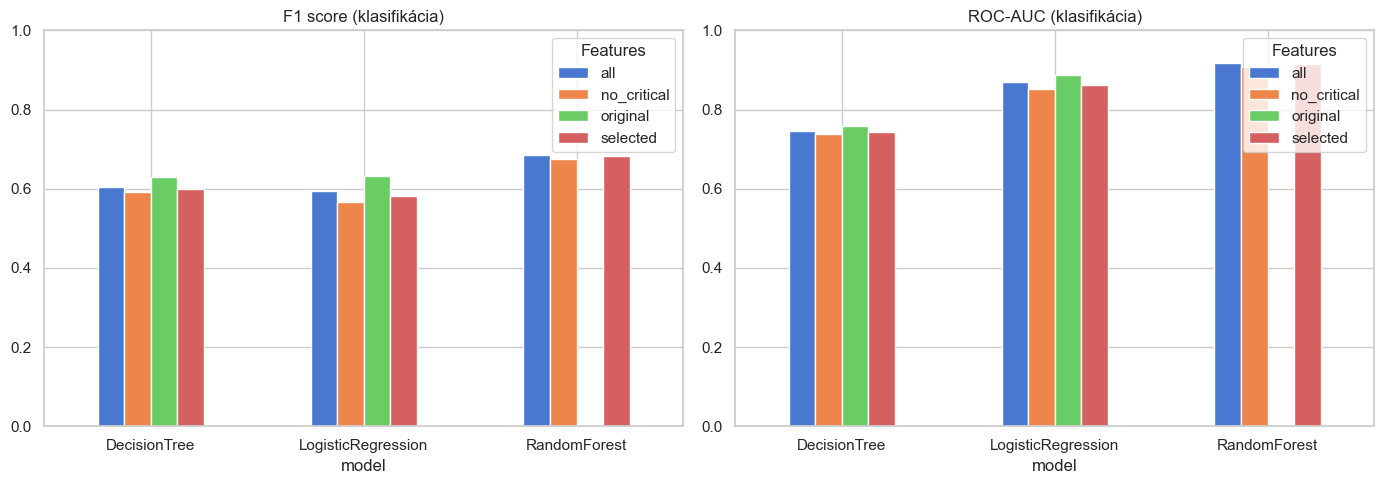

In [ ]:
# Vizualizácia: F1 porovnanie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Klasifikácia — F1
pivot_f1 = cls_results.pivot(index='model', columns='features', values='f1')
pivot_f1.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('F1 score (klasifikácia)')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Features')

# Klasifikácia — AUC
pivot_auc = cls_results.pivot(index='model', columns='features', values='roc_auc')
pivot_auc.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('ROC-AUC (klasifikácia)')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Features')

plt.tight_layout()
plt.savefig('outputs/phase1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Fáza 2: Ladenie hyperparametrov

Na základe výsledkov Fázy 1 vyberieme najlepší model a feature set.

In [ ]:
# === Hyperparametre pre jednotlivé modely ===

param_grids = {
    'DecisionTree': {
        'model__max_depth': [5, 10, 15, 20, None],
        'model__min_samples_split': randint(2, 30),
        'model__min_samples_leaf': randint(1, 20),
        'model__criterion': ['gini', 'entropy'],
    },
    'LogisticRegression': {
        'model__C': uniform(0.01, 10),
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['saga'],
    },
    'RandomForest': {
        'model__n_estimators': randint(100, 500),
        'model__max_depth': [10, 20, 30, None],
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 10),
        'model__max_features': ['sqrt', 'log2', 0.3],
    },
}

In [ ]:
# === Tuning najlepšieho modelu ===
# Uprav best_model_name a best_fs_name podľa výsledkov Fázy 1

best_model_name = 'RandomForest'   # <- uprav podľa Fázy 1
best_fs_name = 'selected'          # <- uprav podľa Fázy 1

best_pipeline = clf_models[best_model_name]
best_features = feature_sets[best_fs_name]
X_best = df[best_features]

search = RandomizedSearchCV(
    best_pipeline,
    param_grids[best_model_name],
    n_iter=30,
    cv=cv_cls,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_best, y_cls)

print(f"Best F1: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

In [ ]:
# Porovnanie: default vs tuned
default_f1 = cls_results.loc[(cls_results['model'] == best_model_name) & (cls_results['features'] == best_fs_name), 'f1'].values[0]
print(f"{best_model_name} ({best_fs_name}):")
print(f"  Default F1: {default_f1:.4f}")
print(f"  Tuned F1:   {search.best_score_:.4f}")
print(f"  Zlepšenie:  {search.best_score_ - default_f1:+.4f}")